# EDA
# Imports 
    

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt 
import os
from dotenv import load_dotenv

2026-03-05 17:28:06.988542: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 17:28:06.996009: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 17:28:07.312192: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 17:28:08.920607: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
print(f"tf version : {tf.__version__}")

tf version : 2.20.0


## Loading & Preprocessing 
### fix path

In [3]:
data_dir = os.getenv("data_notebook_path")
train_data = os.path.join(data_dir, "train")       # Colab : after unzip'data.zip' => DATA_DIR = "/content/data"
test_data =os.path.join(data_dir, "test")

### Datasets Parameters

In [4]:
BATCH_SIZE = 32     # samples : 16, 32, 64, 128
IMG_HEIGHT = 48     # DATASET size: 48 * 48
IMG_WIDTH = 48
NUM_CLASSES = 7     # (angry, disgust, fear, happy, neutral, sad, surprise)
AUTOTUNE = tf.data.AUTOTUNE     # optimize loading

### loading data 

In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(    # 28709 images
    train_data,
    label_mode = 'int',      # labels : int (0,1,2,...) ------
    color_mode = 'grayscale',
    image_size = (IMG_HEIGHT,IMG_WIDTH),
    batch_size = BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(     # 7178 images
    test_data,
    label_mode = 'int',
    color_mode = 'grayscale',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"Class Names : {class_names}")


Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Class Names : ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


2026-03-05 17:28:10.137507: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Normalization

In [6]:
normalized_layer = layers.Rescaling(1./255)     # Keras layer :  [0,255] --> [0,1]

# Normalization ---> train/test Datasets
train_dataset = train_dataset.map(lambda x, y : (normalized_layer(x),y))
test_dataset = test_dataset.map(lambda x, y: (normalized_layer(x),y))

### Optimizing Performance

In [7]:
# cache(): Keeps data in memory (RAM)
# prefetch(): Pre-loads data batches ahead of time
train_dataset = train_dataset.cache().prefetch(buffer_size = AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size = AUTOTUNE)

print("\n")
print("=> Data is loaded, normalized & optimized")




=> Data is loaded, normalized & optimized


### visualization

2026-03-05 17:28:10.492964: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-05 17:28:10.565293: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


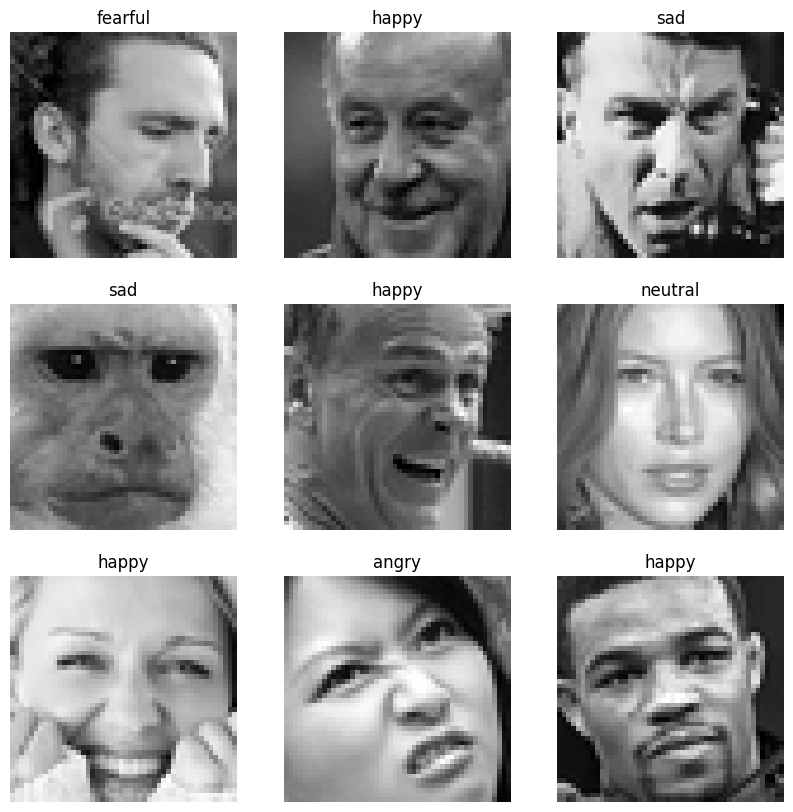

In [8]:
plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):    # 1 batch
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().reshape(48,48), cmap = 'gray')
        plt.title(class_names[labels[i]])
        plt.axis("off")
        
plt.show()

--------------------------------------------------------------------------------------------------------------
Classes trouvées : [***'angry'***, ***'disgust'***, ***'fear'***, ***'happy'***, ***'neutral'***, ***'sad'***, ***'surprise'***]

* --- Statistiques des Classes (Train) ---
    * Classe **'angry'**: 3995 images
    * Classe **'disgust'**: 436 images
    * Classe **'fear'**: 4097 images
    * Classe **'happy'**: 7215 images
    * Classe **'neutral'**: 4965 images
    * Classe **'sad'**: 4830 images
    * Classe **'surprise'**: 3171 images
        * **Total**: 28709 images

# Détection de visages avec OpenCV et Haar Cascade


In [9]:
# import cv2
# import os

# # --- Definir les chemins Machine Learning\haarcascade-frontalface-default.xml
# cascade_path = "src/haarcascade-frontalface-default.xml"     # modele XML
# image_path = "./Data_Kaggle_Emotional_Detection/train/happy/im7.png"      # image à detecter
# output_path = "result_image.jpg"    # output file Name

# # --- verifier si les fichiers existent
# if not os.path.exists(cascade_path):
#     print(f"Erreur : fichier cascade introuvable dans {cascade_path}")
#     exit()

# if not os.path.exists(image_path):
#     print(f"Erreur : image introuvable dans {image_path}")
#     exit()

# # --- loading Classifier & image
# print("Chargement du modele Haar Cascade...")
# face_cascade = cv2.CascadeClassifier(cascade_path)      # Creer detecteur & Charger XML

# print("Chargement d'image...")
# image = cv2.imread(image_path)

# # --- Pretraitement (Crucial) ---
# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# # --- lancer la detection
# print("Detection de Visage...")

# # Faces : liste de rectangles (x, y, Width, Height)
# faces = face_cascade.detectMultiScale(
#     gray,
#     scaleFactor=1.1,  # À quel point réduire l'image à chaque "passage"
#     minNeighbors=5,   # Combien de "voisins" chaque rectangle doit avoir
#     minSize=(30, 30)  # La taille minimale d'un visage à détecter
# )

# print(f"Trouvé : {len(faces)} visage(s) !")

# # --- Dessiner les rectangles ---
# # Boucle sur chaque visage/rectangle trouvé 
# for (x, y, w, h) in faces:
#    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
#    """ Dessine un rectangle sur l'image ORIGINALE (couleur)
#     (x, y) = coin supérieur gauche
#     (x+w, y+h) = coin inférieur droit
#     (0, 255, 0) = couleur (Red, Green, Blue) 
#     2 = épaisseur de la ligne
#     """ 
# # --- Sauvegarder le résultat ---
# cv2.imwrite(output_path, image)
# print(f"Image sauvegardée sous : {output_path}")

# # image --> fenêtre
# cv2.imshow('Visages trouvés', image)
# cv2.waitKey(0)      # Attend qu'on appuie sur une touche
# cv2.destroyAllWindows()

# # imdecode()  /  imread()  /   imwrite()  / imshow()